## Images: compression and denoising in 2D

An image is just a point cloud: one point per pixel centre, one value per point. Nothing in the
samplet construction knows that the points form a grid, and the last section of this notebook
exploits that: the same code denoises an image sampled at **randomly scattered** locations,
where a classical 2D wavelet transform does not apply at all.

In [44]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## The image as a point cloud

grace_hopper.jpg (matplotlib sample data):  600 x 512 = 307200 points, tree in 1.29 s
samplet transform of 307200 values: 0.0070 s


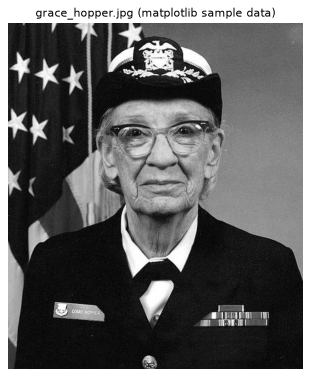

In [45]:
import matplotlib.cbook as cbook

n = 1024
try:
    raw = plt.imread(cbook.get_sample_data("grace_hopper.jpg"))
    img = (raw[..., :3].astype(float) @ np.array([0.2989, 0.5870, 0.1140]))[:n, :n] / 255.0
    title = "grace_hopper.jpg (matplotlib sample data)"
except Exception:                                  # offline fallback: a synthetic image
    gy, gx = np.mgrid[0:n, 0:n] / (n - 1)
    img = (0.5 + 0.4 * np.sin(8 * np.pi * gx) * np.cos(6 * np.pi * gy)
           + 0.4 * ((gx - 0.6) ** 2 + (gy - 0.4) ** 2 < 0.03))
    img = np.clip(img, 0, 1)
    title = "synthetic test image"

ny, nx = img.shape
gx, gy = np.meshgrid(np.arange(nx) / (nx - 1), np.arange(ny) / (ny - 1))
P = np.array(np.vstack([gx.ravel(), gy.ravel()]), order="F")
N = P.shape[1]

t0 = time.time()
ST = FMCA.SampletTree(P, 3)
print(f"{title}:  {ny} x {nx} = {N} points, tree in {time.time() - t0:.2f} s")

idx = ST.indices()
f = np.asfortranarray(img.ravel()[idx].reshape(-1, 1))   # cluster order
t0 = time.time()
c = ST.sampletTransform(f)
print(f"samplet transform of {N} values: {time.time() - t0:.4f} s")

def to_image(vec_cluster_order):
    """undo the cluster ordering and reshape back to a picture"""
    out = np.empty(N)
    out[idx] = np.asarray(vec_cluster_order).ravel()
    return out.reshape(ny, nx)

plt.figure(figsize=(4.6, 4.6))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title(title, fontsize=10)
plt.axis("off")
plt.show()

## Compression: keep the largest coefficients

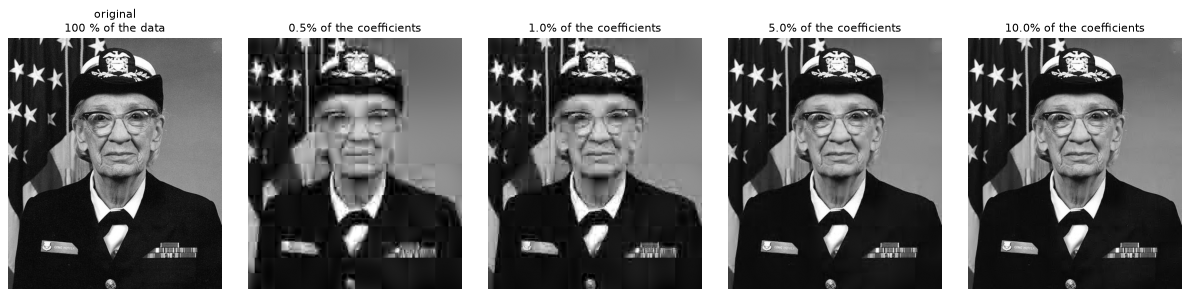

In [46]:
def best_k_term(coeffs, k):
    out = np.zeros_like(coeffs)
    sel = np.argpartition(np.abs(coeffs.ravel()), -k)[-k:]
    out.ravel()[sel] = coeffs.ravel()[sel]
    return np.asfortranarray(out)


keeps = [0.005, 0.01, 0.05, 0.10]
fig, axes = plt.subplots(1, len(keeps) + 1, figsize=(15, 3.6))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("original\n100 % of the data", fontsize=10)
for ax, keep in zip(axes[1:], keeps):
    k = int(keep * N)
    rec = to_image(ST.inverseSampletTransform(best_k_term(c, k)))
    ax.imshow(rec, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{keep:.1%} of the coefficients", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.show()

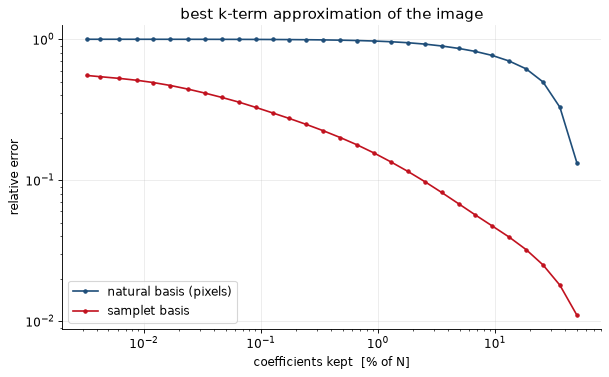

In [47]:
ks = np.unique(np.logspace(1, np.log10(N / 2), 30).astype(int))
err_s = [np.linalg.norm(ST.inverseSampletTransform(best_k_term(c, k)) - f)
         / np.linalg.norm(f) for k in ks]
err_n = [np.linalg.norm(best_k_term(f, k) - f) / np.linalg.norm(f) for k in ks]

plt.figure(figsize=(7.5, 4.6))
plt.loglog(100 * ks / N, err_n, "o-", ms=3, color=C_DATA, label="natural basis (pixels)")
plt.loglog(100 * ks / N, err_s, "o-", ms=3, color=C_SAMP, label="samplet basis")
plt.xlabel("coefficients kept  [% of N]")
plt.ylabel("relative error")
plt.title("best k-term approximation of the image")
plt.legend()
plt.show()

## Denoising

Same recipe as in 1D. For a natural image the universal threshold is a little too aggressive
(images are not smooth), so a fraction of it is used; a short sweep finds the best value.

universal threshold 0.503, factor 0.50 -> threshold 0.251, 13278 of 307200 coefficients kept


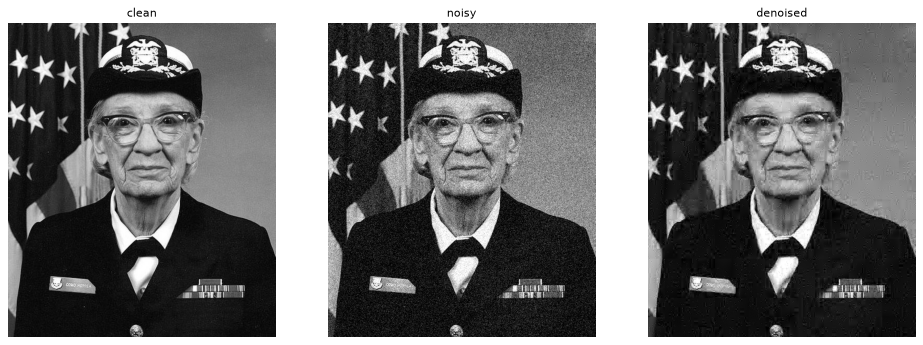

In [48]:
rng = np.random.default_rng(7)
sigma = 0.1
noisy = img + sigma * rng.standard_normal(img.shape)
c_noisy = ST.sampletTransform(np.asfortranarray(noisy.ravel()[idx].reshape(-1, 1)))

lam_univ = sigma * np.sqrt(2 * np.log(N))
fac = 0.5
cc = np.where(np.abs(c_noisy) > fac * lam_univ, c_noisy, 0.0)
cc[:ST.nscalfs()] = c_noisy[:ST.nscalfs()]
den = to_image(ST.inverseSampletTransform(np.asfortranarray(cc)))

print(f"universal threshold {lam_univ:.3f}, factor {fac:.2f} "
      f"-> threshold {fac * lam_univ:.3f}, {int((cc != 0).sum())} of {N} coefficients kept")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (pic, ttl) in zip(axes, [(img, "clean"),
                                 (noisy, f"noisy"),
                                 (den, f"denoised")]):
    ax.imshow(np.clip(pic, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(ttl, fontsize=10)
    ax.axis("off")
plt.show()